# CNN Sequence-Length Analysis

This notebook independently evaluates whether `CNN_MAX_LENGTH = 1000` is a reasonable preprocessing choice for the IMDb TextCNN experiment.

It reproduces the main notebook's data split, tokeniser, vocabulary construction, and review-encoding rules, but it does **not** train an embedding or CNN. Only the training and validation splits are analysed; the test split is not used for hyperparameter selection.

Run all cells from top to bottom. The final cell generates an English paragraph that can be adapted for the report.

In [1]:
import html
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8-whitegrid")

c:\Users\lulu\anaconda3\envs\yolo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Data split
DATASET_NAME = "Kwaai/IMDB_Sentiment"
VALID_RATIO = 0.20
SEED = 42

# Vocabulary construction
VOCAB_SIZE = 8_000
DROP_TOP_N = 50
PROTECTED_TOKENS = {
    "not", "no", "never", "neither", "nor",
    "but", "however", "although", "though", "yet",
    "good", "bad", "great", "best", "worst",
    "like", "love", "hate", "enjoy",
    "very", "really", "too", "so", "just",
    "more", "most", "less", "least",
    "hardly", "barely", "scarcely",
}

# CNN input-length analysis
CNN_MAX_LENGTH = 1_000
CANDIDATE_LENGTHS = [
    200,
    400,
    600,
    800,
    1_000,
    1_200,
    1_500,
    2_000,
]

assert CNN_MAX_LENGTH in CANDIDATE_LENGTHS

In [3]:
raw_dataset = load_dataset(DATASET_NAME)

labelled_split = raw_dataset["train"].train_test_split(
    test_size=VALID_RATIO,
    seed=SEED,
    stratify_by_column="label",
)

train_dataset = labelled_split["train"]
valid_dataset = labelled_split["test"]

print(
    f"Training reviews:   {len(train_dataset):,}\n"
    f"Validation reviews: {len(valid_dataset):,}"
)

assert len(train_dataset) == 20_000
assert len(valid_dataset) == 5_000

Training reviews:   20,000
Validation reviews: 5,000


In [4]:
BREAK_PATTERN = re.compile(
    r"<br\s*/?>",
    flags=re.IGNORECASE,
)
TOKEN_PATTERN = re.compile(
    r"[a-z]+(?:'[a-z]+)?|[!?]+|[:;=8xX][\-^']?[)(/\\dDpP]"
)


def tokenise(text):
    text = html.unescape(text)
    text = BREAK_PATTERN.sub(" ", text)
    return TOKEN_PATTERN.findall(text.lower())


print(tokenise(
    "This movie isn't good! <br /> But I liked the ending :)"
))

['this', 'movie', "isn't", 'good', '!', 'but', 'i', 'liked', 'the', 'ending', ':)']


In [5]:
token_counts = Counter()

for text in tqdm(
    train_dataset["text"],
    desc="Building the training vocabulary",
):
    token_counts.update(tokenise(text))

ranked_tokens = token_counts.most_common()


def is_protected_token(token):
    return (
        token in PROTECTED_TOKENS
        or token.endswith("n't")
        or re.fullmatch(r"[!?]+", token) is not None
    )


ignored_tokens = [
    token
    for token, _ in ranked_tokens
    if not is_protected_token(token)
][:DROP_TOP_N]
ignored_token_set = set(ignored_tokens)

vocabulary_tokens = [
    token
    for token, _ in ranked_tokens
    if token not in ignored_token_set
][:VOCAB_SIZE]

if len(vocabulary_tokens) < VOCAB_SIZE:
    raise ValueError(
        "The training corpus contains fewer tokens than VOCAB_SIZE."
    )

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_ID = 0
UNK_ID = 1

id_to_token = [PAD_TOKEN, UNK_TOKEN] + vocabulary_tokens
token_to_id = {
    token: token_id
    for token_id, token in enumerate(id_to_token)
}

print("Ignored high-frequency tokens:", ignored_tokens)
print("Lexical vocabulary size:", len(vocabulary_tokens))
print("Total lookup-table rows:", len(id_to_token))

Building the training vocabulary: 100%|██████████| 20000/20000 [00:02<00:00, 9905.86it/s] 


Ignored high-frequency tokens: ['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'film', 'on', 'you', 'his', 'are', 'have', 'he', 'be', 'one', 'all', 'at', 'by', 'an', 'they', 'who', 'from', 'her', 'or', 'about', "it's", 'out', 'if', 'has', 'there', 'some', 'what', 'when', 'up', 'even', 'time', 'she', 'my', 'would', 'which']
Lexical vocabulary size: 8000
Total lookup-table rows: 8002


In [6]:
def measure_review_lengths(texts, description):
    raw_lengths = []
    encoded_lengths = []

    for text in tqdm(texts, desc=description):
        tokens = tokenise(text)
        retained_count = sum(
            token in token_to_id
            for token in tokens
        )

        raw_lengths.append(len(tokens))
        encoded_lengths.append(max(1, retained_count))

    return (
        np.asarray(raw_lengths, dtype=np.int32),
        np.asarray(encoded_lengths, dtype=np.int32),
    )


train_raw_lengths, train_encoded_lengths = measure_review_lengths(
    train_dataset["text"],
    "Measuring training review lengths",
)
valid_raw_lengths, valid_encoded_lengths = measure_review_lengths(
    valid_dataset["text"],
    "Measuring validation review lengths",
)

Measuring validation review lengths: 100%|██████████| 5000/5000 [00:00<00:00, 10713.72it/s]


In [17]:
longest_index = int(np.argmax(train_encoded_lengths))
review = train_dataset[longest_index]
text = review["text"]

tokens = tokenise(text)

retained_tokens = [
    token
    for token in tokens
    if token in token_to_id
]

print("Validation index:", longest_index)
print("Label:", review["label"])
print("Characters:", len(text))
print("Raw token count:", len(tokens))
print("Encoded token count:", len(retained_tokens))
print("Removed token count:", len(tokens) - len(retained_tokens))
print(
    "Would be truncated at 1,000:",
    len(retained_tokens) > CNN_MAX_LENGTH,
)

print("\n" + "=" * 80)
print("ORIGINAL REVIEW")
print("=" * 80)
print(text)

print("\n" + "=" * 80)
print("TOKENS RETAINED FOR CNN")
print("=" * 80)
print(" ".join(retained_tokens))

Validation index: 14525
Label: 1
Characters: 13704
Raw token count: 2492
Encoded token count: 1276
Removed token count: 1216
Would be truncated at 1,000: True

ORIGINAL REVIEW
Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris Benoit. According to the rules of the match, both opponents have to go through tables in order to get the win. Benoit and Guerrero heated up early on by taking turns hammering first Spike and then Bubba Ray. A German suplex by Benoit to Bubba took the wind out of the Dudley brother. Spike tried to help his brother, but the referee restrained him while Benoit and Guerrero ganged up on him in the corner. With Benoit stomping away on Bubba, Guerrero set up a table outside. Spike dashed into the ring and somersaulted over the top rope onto Guerrero on the outside! After recovering and taking care of Spike, Guerrero slippe

In [8]:
def summarise_distribution(
    raw_lengths,
    encoded_lengths,
    split,
    max_length,
):
    clipped_lengths = np.minimum(
        encoded_lengths,
        max_length,
    )
    truncated_mask = encoded_lengths > max_length

    return {
        "split": split,
        "reviews": len(encoded_lengths),
        "mean_raw_length": raw_lengths.mean(),
        "mean_encoded_length": encoded_lengths.mean(),
        "median_encoded_length": np.median(encoded_lengths),
        "p90_encoded_length": np.percentile(
            encoded_lengths,
            90,
        ),
        "p95_encoded_length": np.percentile(
            encoded_lengths,
            95,
        ),
        "p99_encoded_length": np.percentile(
            encoded_lengths,
            99,
        ),
        "maximum_encoded_length": encoded_lengths.max(),
        "reviews_over_limit": truncated_mask.sum(),
        "truncated_review_rate": truncated_mask.mean(),
        "retained_token_rate": (
            clipped_lengths.sum() / encoded_lengths.sum()
        ),
    }


length_summary_df = pd.DataFrame([
    summarise_distribution(
        train_raw_lengths,
        train_encoded_lengths,
        "Training",
        CNN_MAX_LENGTH,
    ),
    summarise_distribution(
        valid_raw_lengths,
        valid_encoded_lengths,
        "Validation",
        CNN_MAX_LENGTH,
    ),
])

display(length_summary_df.style.format({
    "mean_raw_length": "{:.1f}",
    "mean_encoded_length": "{:.1f}",
    "median_encoded_length": "{:.1f}",
    "p90_encoded_length": "{:.1f}",
    "p95_encoded_length": "{:.1f}",
    "p99_encoded_length": "{:.1f}",
    "truncated_review_rate": "{:.2%}",
    "retained_token_rate": "{:.2%}",
}))

,split,reviews,mean_raw_length,mean_encoded_length,median_encoded_length,p90_encoded_length,p95_encoded_length,p99_encoded_length,maximum_encoded_length,reviews_over_limit,truncated_review_rate,retained_token_rate
0,Training,20000,234.0,123.4,92.0,243.0,315.0,469.0,1276,1,0.01%,99.99%
1,Validation,5000,232.4,122.2,93.0,235.0,305.0,466.0,888,0,0.00%,100.00%


In [18]:
def analyse_limit(lengths, max_length):
    clipped_lengths = np.minimum(lengths, max_length)
    removed_lengths = lengths - clipped_lengths
    truncated_mask = lengths > max_length

    return {
        "max_length": max_length,
        "truncated_reviews": truncated_mask.sum(),
        "truncated_review_rate": truncated_mask.mean(),
        "retained_token_rate": (
            clipped_lengths.sum() / lengths.sum()
        ),
        "removed_token_rate": (
            removed_lengths.sum() / lengths.sum()
        ),
        "mean_length_after_truncation": (
            clipped_lengths.mean()
        ),
        "mean_tokens_removed_per_truncated_review": (
            removed_lengths[truncated_mask].mean()
            if truncated_mask.any()
            else 0.0
        ),
    }

length_comparison_df = pd.DataFrame([
    analyse_limit(train_encoded_lengths, max_length)
    for max_length in CANDIDATE_LENGTHS
])

length_comparison_df["additional_retention_from_previous"] = (
    length_comparison_df["retained_token_rate"].diff()
)

display(length_comparison_df.style.format({
    "truncated_review_rate": "{:.2%}",
    "retained_token_rate": "{:.2%}",
    "removed_token_rate": "{:.2%}",
    "mean_length_after_truncation": "{:.1f}",
    "mean_tokens_removed_per_truncated_review": "{:.1f}",
    "additional_retention_from_previous": "{:.2%}",
}))

,max_length,truncated_reviews,truncated_review_rate,retained_token_rate,removed_token_rate,mean_length_after_truncation,mean_tokens_removed_per_truncated_review,additional_retention_from_previous
0,200,2988,14.94%,87.74%,12.26%,108.3,101.3,nan%
1,400,444,2.22%,98.63%,1.37%,121.8,76.0,10.89%
2,600,14,0.07%,99.90%,0.10%,123.3,171.9,1.27%
3,800,3,0.01%,99.97%,0.03%,123.4,251.0,0.07%
4,1000,1,0.01%,99.99%,0.01%,123.4,276.0,0.02%
5,1200,1,0.01%,100.00%,0.00%,123.4,76.0,0.01%
6,1500,0,0.00%,100.00%,0.00%,123.4,0.0,0.00%
7,2000,0,0.00%,100.00%,0.00%,123.4,0.0,0.00%


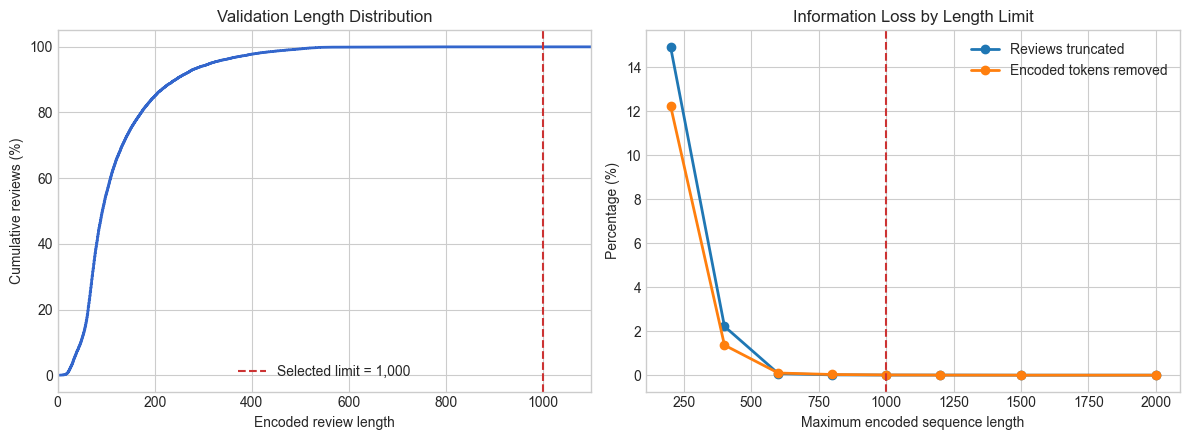

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sorted_lengths = np.sort(train_encoded_lengths)
cumulative_proportion = (
    np.arange(1, len(sorted_lengths) + 1)
    / len(sorted_lengths)
)

axes[0].plot(
    sorted_lengths,
    cumulative_proportion * 100,
    color="#3366cc",
    linewidth=2,
)
axes[0].axvline(
    CNN_MAX_LENGTH,
    color="#cc3333",
    linestyle="--",
    label="Selected limit = 1,000",
)
axes[0].set_xlim(
    0,
    max(
        CNN_MAX_LENGTH * 1.1,
        np.percentile(valid_encoded_lengths, 99.5),
    ),
)
axes[0].set_xlabel("Encoded review length")
axes[0].set_ylabel("Cumulative reviews (%)")
axes[0].set_title("Validation Length Distribution")
axes[0].legend()

axes[1].plot(
    length_comparison_df["max_length"],
    length_comparison_df["truncated_review_rate"] * 100,
    marker="o",
    linewidth=2,
    label="Reviews truncated",
)
axes[1].plot(
    length_comparison_df["max_length"],
    length_comparison_df["removed_token_rate"] * 100,
    marker="o",
    linewidth=2,
    label="Encoded tokens removed",
)
axes[1].axvline(
    CNN_MAX_LENGTH,
    color="#cc3333",
    linestyle="--",
)
axes[1].set_xlabel("Maximum encoded sequence length")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Information Loss by Length Limit")
axes[1].legend()

plt.tight_layout()
plt.show()